In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
df = pd.read_csv("../data/Mall_Customers.csv")

In [11]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [24]:
print(df.shape)
print(df['Annual Income (k$)'].shape)
print(df['Spending Score (1-100)'].shape)

(200, 5)
(200,)
(200,)


In [25]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [16]:
print("\n 'Annual income' column data : ")
print(df['Annual Income (k$)'])


 'Annual income' column data : 
0       15
1       15
2       16
3       16
4       17
      ... 
195    120
196    126
197    126
198    137
199    137
Name: Annual Income (k$), Length: 200, dtype: int64


In [28]:
mv = df.isnull()
print(mv)

     CustomerID  Gender    Age  Annual Income (k$)  Spending Score (1-100)
0         False   False  False               False                   False
1         False   False  False               False                   False
2         False   False  False               False                   False
3         False   False  False               False                   False
4         False   False  False               False                   False
..          ...     ...    ...                 ...                     ...
195       False   False  False               False                   False
196       False   False  False               False                   False
197       False   False  False               False                   False
198       False   False  False               False                   False
199       False   False  False               False                   False

[200 rows x 5 columns]


In [30]:
df[["Annual Income (k$)", "Spending Score (1-100)"]].describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [31]:
df[["Gender", "Age"]].groupby("Gender").mean()

,Age
Gender,
Female,38.098214
Male,39.806818


In [17]:
print("\n 'Spending Score (1-100)' column data :")
print(df['Spending Score (1-100)'])


 'Spending Score (1-100)' column data :
0      39
1      81
2       6
3      77
4      40
       ..
195    79
196    28
197    74
198    18
199    83
Name: Spending Score (1-100), Length: 200, dtype: int64


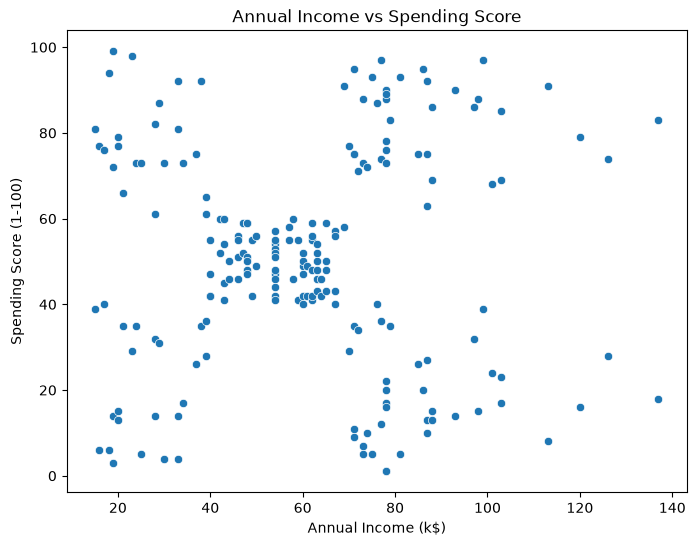

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [39]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [40]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [41]:
X.shape

(200, 2)

In [54]:
import importlib
import customer_segmentation.preprocessing as preprocessing

importlib.reload(preprocessing)

print(dir(preprocessing))

['StandardScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'scale_features']


In [55]:
from customer_segmentation.preprocessing import scale_features

X_scaled , scaler = scale_features(X)

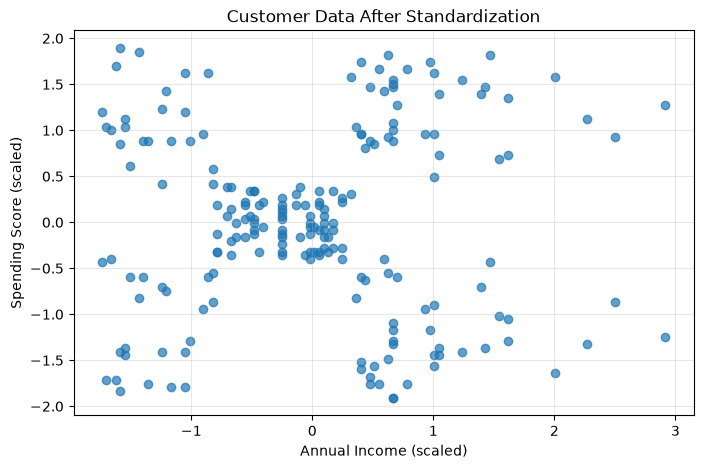

In [56]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:,1],
    alpha = 0.7
)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Data After Standardization")
plt.grid(True, alpha=0.3)
plt.show()
        

In [60]:
import importlib
import customer_segmentation.clustering as clustering

importlib.reload(clustering)

print(dir(clustering))

['KMeans', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'elbow_method', 'find_optimal_k', 'silhouette_score', 'train_kmeans']


In [61]:
from customer_segmentation.clustering import(
    elbow_method,
    find_optimal_k,
    train_kmeans
)

In [64]:
k_values = range(1, 11)
wcss = elbow_method(X_scaled)

ValueError: x and y must have same first dimension, but have shapes (10,) and (2,)

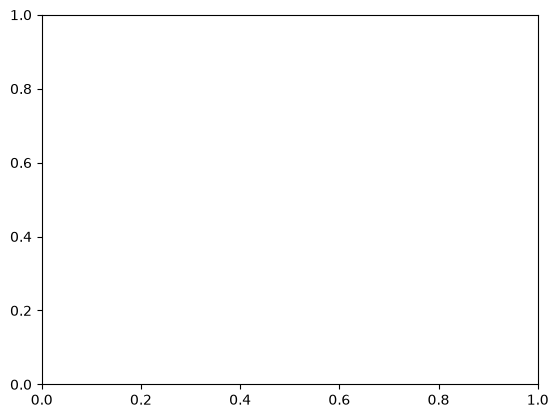

In [65]:
import matplotlib.pyplot as plt

plt.plot(k_values, wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,10):
    kmeans = KMeans(
        n_clusters= k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

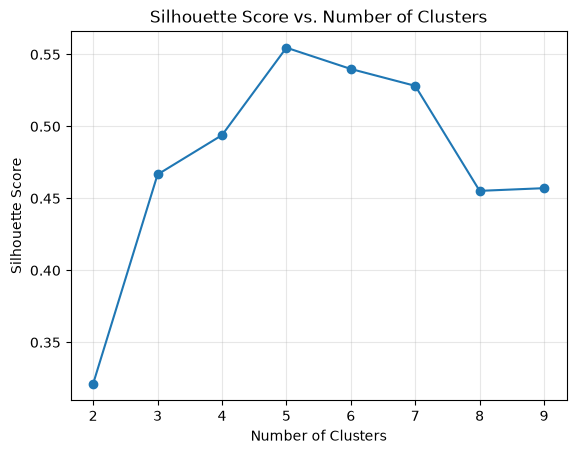

In [56]:
plt.plot(range(2, 10), scores, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.show()


In [11]:
# Train the final model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [12]:
print(df[["Annual Income (k$)", "Spending Score (1-100)", "Cluster"]])

     Annual Income (k$)  Spending Score (1-100)  Cluster
0                    15                      39        4
1                    15                      81        2
2                    16                       6        4
3                    16                      77        2
4                    17                      40        4
..                  ...                     ...      ...
195                 120                      79        1
196                 126                      28        3
197                 126                      74        1
198                 137                      18        3
199                 137                      83        1

[200 rows x 3 columns]


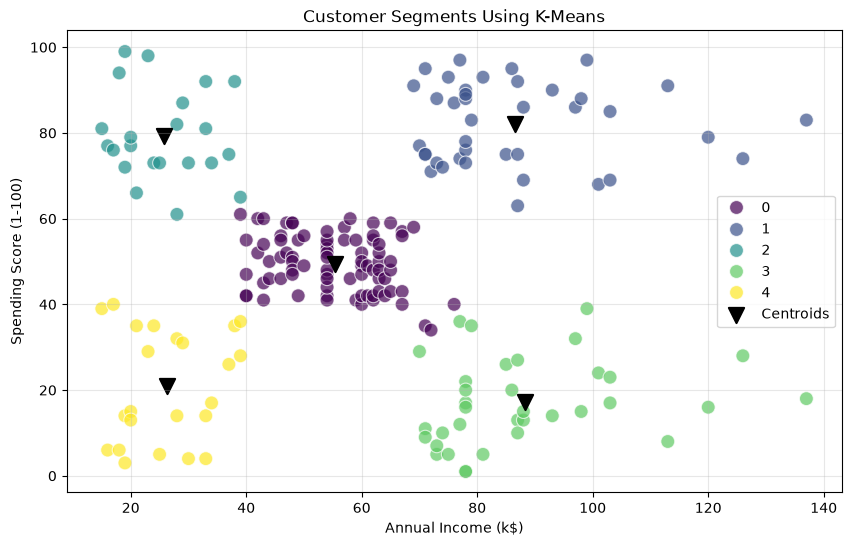

In [27]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids, 
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=100,
    alpha=0.7
)

plt.scatter(
    centroids_df["Annual Income (k$)"],
    centroids_df["Spending Score (1-100)"],
    marker="v",
    s=120,
    color="black",
    edgecolors="black",
    linewidths=1.5,
    label="Centroids"
)

plt.title("Customer Segments Using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
cluster_statistics = df.groupby("Cluster").agg({
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
}).rename(columns={
    "Annual Income (k$)": "Average Income",
    "Spending Score (1-100)": "Average Spending Score",
    "CustomerID": "Number of Cusyomers"
})
print(cluster_statistics.round(2))

         Average Income  Average Spending Score  Number of Cusyomers
Cluster                                                             
0                 55.30                   49.52                   81
1                 86.54                   82.13                   39
2                 25.73                   79.36                   22
3                 88.20                   17.11                   35
4                 26.30                   20.91                   23


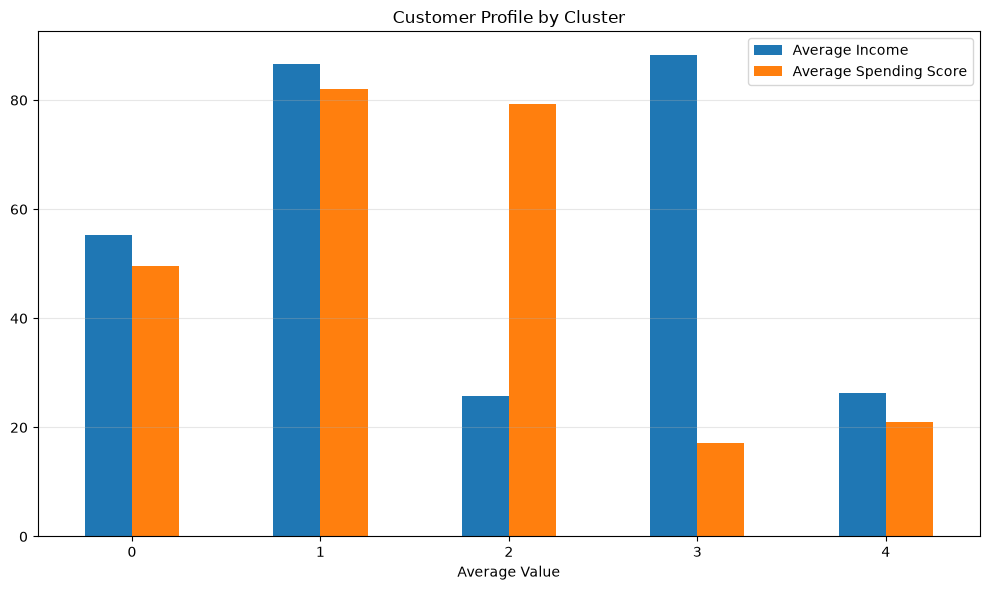

In [29]:
cluster_statistics[
    ["Average Income", "Average Spending Score"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Customer Profile by Cluster")
plt.xlabel("Average Value")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
cluster_names = {
    0: "Moderate customer activity",
    1: "High-value, active spenders",
    2: "Active spenders with lower incomes",
    3: "Affluent customers with growth potential",
    4: "Lower-spending customers"
}
df["segment"] = df["Cluster"].map(cluster_names)

In [31]:
segment_summary = df.groupby("segment").agg(
    Average_Icome=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean"),
    Number_of_Customers=("CustomerID", "count")
).round(2)

print(segment_summary)

                                          Average_Icome  Average_Spending  \
segment                                                                     
Active spenders with lower incomes                25.73             79.36   
Affluent customers with growth potential          88.20             17.11   
High-value, active spenders                       86.54             82.13   
Lower-spending customers                          26.30             20.91   
Moderate customer activity                        55.30             49.52   

                                          Number_of_Customers  
segment                                                        
Active spenders with lower incomes                         22  
Affluent customers with growth potential                   35  
High-value, active spenders                                39  
Lower-spending customers                                   23  
Moderate customer activity                                 81  


### Business Interpretation and Key Findings

The K-Means model identified five customer segments based on annual income and spending score.

* **High-value customers:** Customers with high incomes and high spending scores who may benefit from retention strategies and personalized rewards.
* **Affluent, low-spending customers:** Customers with high incomes but low spending scores who represent a potential opportunity for targeted engagement.
* **Active spenders with lower incomes:** Customers who demonstrate high spending scores despite lower average incomes.
* **Low-income, low-spending customers:** Customers whose engagement may respond to relevant, affordable offers.
* **Average customers:** The largest segment, characterized by moderate income and spending scores, providing an opportunity for personalized marketing.

These segments can help a retailer design more targeted marketing strategies. However, the recommendations should be validated using actual purchase histories and campaign results before making business decisions.
